<a href="https://colab.research.google.com/github/aldo02032004/naufaldo.github.io/blob/main/WorkCloud_Vizualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1 — Imports

In [ ]:
!pip install emoji ftfy Sastrawi

import re                      # dipakai di clean_text() untuk semua pola regex (hapus URL, mention, hashtag, angka, tanda baca, dll)
import emoji                   # dipakai di clean_text() -> emoji.replace_emoji(text, replace=' ')
import ftfy                    # dipakai di clean_text() -> ftfy.fix_text(text) untuk perbaiki encoding rusak
import pandas as pd            # dipakai untuk semua operasi dataframe (classified_df, raw_df, dll)
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # dipakai -> stopword_factory = StopWordRemoverFactory()
from sklearn.feature_extraction.text import CountVectorizer  # dipakai di Cell 10 untuk hitung frekuensi n-gram (1,2)
from wordcloud import WordCloud  # dipakai untuk generate word cloud
import matplotlib.pyplot as plt  # dipakai untuk menampilkan word cloud
from tqdm.auto import tqdm       # dipakai untuk progress bar -> tqdm.pandas() lalu classified_df[...].progress_apply(clean_text)

# Cell 2 - Konstanta & Helper Kolom

In [ ]:
PLATFORM_ORDER = [
    "Media Mainstream", "Twitter", "Instagram",
    "Youtube", "Facebook", "Thread", "Tiktok",
]

_COLUMN_RENAME_MAP = {
    # "Platform": "Media",
    # "Sentimen": "Sentiment",
}


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip().title() for c in df.columns]
    df = df.rename(columns=_COLUMN_RENAME_MAP)
    return df

# Cell 3 - Load Data

In [ ]:
def load_from_gsheet_link(sheet_url, header_row=1):
    match_id = re.search(r"/d/([a-zA-Z0-9-_]+)", sheet_url)
    if not match_id:
        raise ValueError("Sheet ID tidak ditemukan di URL. Pastikan link-nya benar.")
    sheet_id = match_id.group(1)

    match_gid = re.search(r"gid=(\d+)", sheet_url)
    gid = match_gid.group(1) if match_gid else "0"

    csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    df = pd.read_csv(csv_url, skiprows=header_row)
    df = _normalize_columns(df)
    return df

# Cell 4 - Klasifikasi (Media/Sentiment/Author)

In [ ]:
_DOMAIN_PATTERNS = {
    "Twitter":   [r"twitter\.com", r"\bx\.com"],
    "Instagram": [r"instagram\.com"],
    "Youtube":   [r"youtube\.com", r"youtu\.be"],
    "Facebook":  [r"facebook\.com", r"fb\.watch"],
    "Tiktok":    [r"tiktok\.com"],
    "Thread":    [r"threads\.(com|net)"],
}

def classify_media_type(link: str) -> str:
    if not isinstance(link, str):
        return "Media Mainstream"
    link_lower = link.lower()
    for platform, patterns in _DOMAIN_PATTERNS.items():
        if any(re.search(p, link_lower) for p in patterns):
            return platform
    return "Media Mainstream"


def classify_sentiment(text: str) -> str:
    return "neutral"


_DOMAIN_LIKE_PATTERN = re.compile(r"^[^\s@]+\.[a-z]{2,}$", re.IGNORECASE)

_MEDIA_NAME_KEYWORDS = [
    "berita", "news", "media", "tv", "official", "redaksi", "pers",
    "kompas", "detik", "tempo", "cnn", "cnbc", "republika", "tribun",
    "liputan6", "antara", "metro tv", "sindonews", "okezone", "kumparan",
    "suara.com", "viva", "merdeka.com", "idn times", "jpnn",
]

def classify_author_type(author_name: str = "") -> str:
    name = str(author_name).strip()
    if not name or name.lower() == "nan":
        return "Individual"

    if not name.startswith("@") and _DOMAIN_LIKE_PATTERN.match(name):
        return "Media"

    name_lower = name.lower()
    if any(k in name_lower for k in _MEDIA_NAME_KEYWORDS):
        return "Media"
    return "Individual"

# Cell 5 - Build Classified Dataframe

In [ ]:
_MEDIA_LABEL_NORMALIZATION = {
    "News": "Media Mainstream",
    "Threads": "Thread",
}


def build_classified_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()

    if "Media" in df.columns:
        df["Media"] = df["Media"].replace(_MEDIA_LABEL_NORMALIZATION)
        missing_media = df["Media"].isna() | (df["Media"].astype(str).str.strip() == "")
        df.loc[missing_media, "Media"] = df.loc[missing_media, "Link"].apply(classify_media_type)
    else:
        df["Media"] = df["Link"].apply(classify_media_type)

    if "Sentiment" in df.columns:
        df["Sentiment"] = df["Sentiment"].astype(str).str.strip().str.lower()
        missing_sentiment = df["Sentiment"].isin(["", "nan", "none"])
        if missing_sentiment.any():
            df.loc[missing_sentiment, "Sentiment"] = df.loc[missing_sentiment, "Mentions"].apply(
                classify_sentiment
            )
    else:
        df["Sentiment"] = df["Mentions"].apply(classify_sentiment)

    df["Author_Type"] = df["Author"].apply(classify_author_type)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    return df

# Cell 6 - Load & Classified Data

In [ ]:
raw_df = load_from_gsheet_link(
    "https://docs.google.com/spreadsheets/d/1bforai6lD-kdyL9jBGI8Iyl65XWc3wTd/edit?gid=2054570055",
    header_row=1,
)
classified_df = build_classified_dataframe(raw_df)
classified_df.head()

,No,Type,Headline,Mentions,Date,Link,Media,Sentiment,Author,Followers,Retweeted,Favourited,Location,Author_Type
0,1,mention,IRONIS!! YANG TANGANI KORUPSI TERNYATA KORUPTO...,IRONIS!! YANG TANGANI KORUPSI TERNYATA KORUPTO...,2026-08-31 23:59:28,https://www.youtube.com/watch?v=YZiE-GTBWpM,Youtube,negative,Bedah Berita,0,0,0,NaN,Media
1,2,rt,NaN,RT FAKKK YUUU PRABOWO https://t.co/gmCcqQWLu7,2026-08-31 23:59:18,https://twitter.com/web/statuses/2094470096022...,Twitter,negative,@syhlaaaa,22,0,0,NaN,Individual
2,3,rt,NaN,RT FAKKK YUUU PRABOWO https://t.co/gmCcqQWLu7,2026-08-31 23:59:01,https://twitter.com/web/statuses/2094470024002...,Twitter,negative,@shabashashibisi,641,0,0,NaN,Individual
3,4,rt,NaN,"RT Damn ,ternyata hidup gw dimasa covid gaada ...",2026-08-31 23:59:00,https://twitter.com/web/statuses/2094470020307...,Twitter,negative,@sinceday1to6,43,0,0,she/her,Individual
4,5,rt,NaN,RT APAKAH JOKOWI AKAN MENGKUDETA PRABOWO? Apa...,2026-08-31 23:58:46,https://twitter.com/web/statuses/2094469961007...,Twitter,negative,@Mughniy19878219,196,0,0,"West Java\, Indonesia",Individual


# Cell 7 - Dictionary Normalisasi & Stopwords

In [ ]:
slang_dict = {
    # === dictionary phase 1 ===
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "tdk": "tidak",
    "bgt": "banget", "yg": "yang", "krn": "karena", "krna": "karena", 'karna':'karena',
    "sm": "sama", "utk": "untuk", "dr": "dari", "skrg": "sekarang",
    "dgn": "dengan", "dg": "dengan", "org": "orang",
    "tp": "tapi", "spt": "seperti", "kayak": "seperti", "kaya": "seperti", "kyk": "seperti",
    "blm": "belum", "jgn": "jangan", "emg": "memang", "emang": "memang",
    "jd": "jadi", "jg": "juga", "aja": "saja", "aj": "saja",
    "udah": "sudah", "udh": "sudah", "dah": "sudah",
    "gmn": "bagaimana", "knp": "kenapa", "kalo": "kalau", "klo": "kalau",
    "trs": "terus", "trus": "terus", "gini": "begini", "gitu": "begitu",
    "sy": "saya", "km": "kamu", "gw": "saya", "gue": "saya", "lo": "kamu", "lu": "kamu",
    "hrs": "harus", "bs": "bisa", "msh": "masih", "dlm": "dalam",
    "sblm": "sebelum", "stlh": "setelah", "pd": "pada", "pgn": "ingin", "pengen": "ingin",
    "liat": "lihat", "abis": "habis",
    "bkn": "bukan", "gpp": "tidak apa-apa", "gapapa": "tidak apa-apa", "gaada": "tidak ada",
    "cmn": "cuma", "cuman": "cuma",
    "mksh": "terima kasih", "makasih": "terima kasih",
    "moga": "semoga", "smoga": "semoga",
    "wkt": "waktu", "cpt": "cepat", "lg": "lagi", "lgi": "lagi",
    "sll": "selalu", "sllu": "selalu", "prnh": "pernah",
    "sndiri": "sendiri", "stiap": "setiap", "byk": "banyak", "dikit": "sedikit",
    "dtg": "datang", "krg": "kurang", "ato": "atau",
    "pke": "pakai", "pake": "pakai", "kudu": "harus", "musti": "harus",
    "denger": "dengar", "kasih": "beri", "bikin": "buat",
    "brp": "berapa", "gmna": "bagaimana", "knpa": "kenapa",
    "walopun": "walaupun",
    "kayanya": "sepertinya", "kykny": "sepertinya", "emgnya": "memangnya",

    # negasi & partikel tanya
    "gk": "tidak", "gak2": "tidak", "kaga": "tidak", "kagak": "tidak",
    "ngga": "tidak", "enggak": "tidak", "tak": "tidak",
    "napa": "kenapa", "ngapain": "sedang apa", "ngapa": "kenapa",

    # kata ganti & sapaan
    "ente": "kamu", "situ": "kamu", "elu": "kamu", "elo": "kamu",
    "gua": "saya", "gwa": "saya", "ane": "saya", "aq": "saya", "aku": "saya",
    "kita": "kita", "qt": "kita",

    # singkatan umum
    "dpt": "dapat", "dapet": "dapat", "sy": "saya",
    "tggl": "tinggal", "tinggl": "tinggal",
    "tmn": "teman", "temen": "teman",
    "sm2": "sama-sama", "sama2": "sama-sama",
    "gmana": "bagaimana", "gimana": "bagaimana",
    "trnyata": "ternyata", "ternyta": "ternyata",
    "krna": "karena", "karna": "karena",
    "jgnkan": "jangankan",
    "sbnrnya": "sebenarnya", "sebenernya": "sebenarnya", "sbnernya": "sebenarnya",
    "sesuatu": "sesuatu",
    "sbg": "sebagai", "sbgai": "sebagai",
    "trhdp": "terhadap", "thd": "terhadap", "thdp": "terhadap",
    "diantaranya": "di antaranya",
    "diantara": "di antara",
    "walaupun": "walaupun", "meskipun": "meskipun", "meski": "meskipun",

    # kata kerja
    "ngerti": "mengerti", "ngerasa": "merasa", "berasa": "terasa",
    "keliatan": "terlihat", "keliatannya": "terlihatnya",
    "nyari": "mencari", "nyoba": "mencoba", "nunggu": "menunggu",
    "ngasih": "memberi", "ngajak": "mengajak", "ngobrol": "berbicara",
    "nyadar": "sadar", "sadar2": "sadar",
    "ngerasain": "merasakan", "ngebayangin": "membayangkan",
    "mikir": "berpikir", "mikirin": "memikirkan",
    "ngomongin": "membicarakan",
    "kesel": "kesal", "sebel": "sebal", "sebal": "sebal",
    "capek": "lelah", "cape": "lelah",
    "males": "malas", "mager": "malas gerak",
    "seneng": "senang", "bahagia": "bahagia",
    "sedih": "sedih",
    "parah": "sangat", "gila": "sangat", "anjir": "sangat", "anjay": "sangat",
    "mantap": "bagus", "mantul": "bagus", "keren": "bagus",
    "jelek": "buruk", "ancur": "hancur", "hancur": "hancur",
    "ngeri": "mengerikan", "serem": "menyeramkan",
    "bego": "bodoh", "goblok": "bodoh", "tolol": "bodoh", "bodo": "bodoh",
    "songong": "sombong", "belagu": "sombong",
    "curhat": "curahan hati",
    "japri": "pesan pribadi",
    "japrii": "pesan pribadi",

    # intensitas & konjungsi
    "bener": "benar", "beneran": "benaran",
    "emank": "memang", "emangnya": "memangnya",
    "makanya": "makanya", "makannya": "makanya",
    "jadinya": "jadinya",
    "makin": "semakin", "kian": "semakin",
    "sangattt": "sangat", "bangettt": "banget",
    "banget2": "banget",

    # angka & waktu gaul
    "skrng": "sekarang", "skarang": "sekarang",
    "besok": "besok", "bsk": "besok",
    "kmrn": "kemarin", "kemaren": "kemarin",
    "td": "tadi", "tadi": "tadi",
    "entar": "nanti", "ntar": "nanti", "nti": "nanti",
    "detik2": "detik-detik",

    # politik/berita spesifik yang sering muncul sebagai slang
    "pemrintah": "pemerintah", "pemerintahan": "pemerintah",
    "korup": "korupsi", "dikorupsi": "korupsi", "ngorupsi": "korupsi",
    "nyolong": "mencuri", "maling": "pencuri",
    "boong": "bohong", "bohong2": "bohong", "hoax": "hoaks", "hoak": "hoaks",
    "settingan": "rekayasa", "settingannya": "rekayasa",
    "php": "janji palsu",
    "somasi": "somasi",
    "ngamuk": "marah", "murka": "marah",
    "protes": "protes", "demo": "demonstrasi", "unjuk rasa": "demonstrasi",

    # typo umum
    "yng": "yang", "dngan": "dengan", "utuk": "untuk",
    "ngga2": "tidak", "smpai": "sampai", "sampe": "sampai",
    "bwt": "buat", "buatt": "buat",
    "jgnlah": "janganlah",
    "tuhh": "tuh", "sihh": "sih", "dehh": "deh",
}

Base_SW = {
    'subscribe', 'shorts', 'channel', 'fyp', 'follow', 'com', 'www',
    'beritaterkini', 'selengkapnya', 'sumber', 'informasi', 'terkini',
    'resmi', 'news', 'video', 'viral', 'berita', 'media', 'sosial', 'rt',
    'langsung', 'ujarnya', 'tulis', 'termuat', 'menyatakan', 'menyebut',
    'dinilai', 'dilihat', 'disampaikan', 'mengatakan', 'sindonews', 'detik',
    'kompas', 'tribun', 'cnnindonesia', 'kumparan', 'tempo', 'nya', 'sih',
    'nih', 'tuh', 'deh', 'dong', 'kok', 'yah', 'lah', 'kan',
    'aja', 'udah', 'sdh', 'sampe', 'tau', 'gitu', 'gini', 'orang', 'bilang',
    'ngomong', 'lihat', 'pakai', 'banget', 'bgt', 'emang', 'kayak', 'kaya',
    'prabowosubianto', 'presidenprabowo', 'kompascom', 'viralvideo',
    'shortvideo', 'youtubeshorts', 'beritaviral', 'trending', 'foryou',
    'short', 'like', 'jagaindonesia', 'anutin', 'live', 'chat', 'streaming',
    'audio', 'komen', 'komentar', 'yuk', 'cek',
    'baca', 'bantu', 'update', 'store', 'quot', 'klik', 'tonton', 'simak',
    'youtube', 'facebook', 'tiktok', 'instagram', 'viralshorts', 'part',
    'lambesahamjja', 'ardisatriawan',
    'januari', 'februari', 'maret', 'april', 'mei', 'juni', 'juli',
    'agustus', 'september', 'oktober', 'november', 'desember',
    'kena', 'kau', 'coba', 'doang', 'gara', 'mah', 'sok', 'pas', 'hati', 'mic',
    'takut', 'allah', 'geger',

    # --- tambahan: kata fungsi generik yang lolos dari Sastrawi ---
    'tersebut', 'menjadi', 'tahun', 'ri', 'lebih', 'satu', 'kata',
    'besar', 'hingga', 'hari', 'kalau', 'terus', 'jadi', 'melalui',
    'program', 'rakyat', 'kali', 'saat', 'para', 'oleh',
    'dapat', 'akan', 'sudah', 'telah', 'masih', 'juga', 'saja',
    'lain', 'lainnya', 'setiap', 'semua', 'banyak', 'beberapa',
    'sebuah', 'suatu', 'seperti', 'antara', 'dalam', 'luar',
}

Add_SW = {
    'prabowo', 'presiden', 'subianto', 'pemerintah', 'president',
    'indonesia', 'nasional', 'bangsa', 'masyarakat', 'publik', 'dunia', 'isu',
    'momen', 'terbaru', 'terbaik', 'langkah', 'kinerja', 'memperkuat', 'menjaga',
    'pertemuan', 'terkait', 'terbuka', 'eks',
}

stopword_factory = StopWordRemoverFactory()
sastrawi_sw = set(stopword_factory.get_stop_words())

ALL_STOPWORDS = sastrawi_sw | Base_SW | Add_SW

# kata negasi tetap dipertahankan (tidak dibuang) -- penting untuk analisis sentimen nanti
NEGATION_WORDS = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa'}
ALL_STOPWORDS = ALL_STOPWORDS - NEGATION_WORDS

print(f"Total ALL_STOPWORDS (unik): {len(ALL_STOPWORDS)}")

# =========================================
# CEK RINGKASAN SETUP
# =========================================
print(f"Jumlah entri slang_dict     : {len(slang_dict)}")
print(f"Jumlah Base_SW              : {len(Base_SW)}")
print(f"Jumlah Add_SW                : {len(Add_SW)}")
print(f"Jumlah stopword Sastrawi     : {len(sastrawi_sw)}")
print(f"Total ALL_STOPWORDS (unik)   : {len(ALL_STOPWORDS)}")

overlap = set(slang_dict.keys()) & ALL_STOPWORDS
if overlap:
    print(f"\n⚠️  Ada {len(overlap)} kata di slang_dict yang JUGA ada di stopword:")
    print(overlap)
else:
    print("\n✅ Tidak ada konflik antara slang_dict dan stopword.")

Total ALL_STOPWORDS (unik): 293
Jumlah entri slang_dict     : 248
Jumlah Base_SW              : 165
Jumlah Add_SW                : 23
Jumlah stopword Sastrawi     : 123
Total ALL_STOPWORDS (unik)   : 293

⚠️  Ada 12 kata di slang_dict yang JUGA ada di stopword:
{'bgt', 'sesuatu', 'aja', 'gitu', 'udah', 'kaya', 'emang', 'sampe', 'kayak', 'kita', 'gini', 'nggak'}


# Cell 8 - Cleaning Teks

In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return ""

    # perbaiki encoding rusak & HTML entity
    text = ftfy.fix_text(text)
    text = re.sub(r'&\w+;|&#\d+;', ' ', text)

    # hapus prefix RT
    text = re.sub(r'^\s*RT\b', ' ', text)

    # hapus URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # hapus mention & hashtag
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)

    # hapus emoji
    text = emoji.replace_emoji(text, replace=' ')

    # lowercase
    text = text.lower()

    # hapus angka
    text = re.sub(r'\d+', ' ', text)

    # hapus tanda baca / karakter non-huruf
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'_', ' ', text)

    # rapikan whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # normalisasi kata slang
    tokens = text.split()
    tokens = [slang_dict.get(tok, tok) for tok in tokens]
    text = ' '.join(tokens)
    tokens = text.replace('-', ' ').split()

    # buang stopword & token pendek
    tokens = [t for t in tokens if t not in ALL_STOPWORDS and len(t) > 1]
    text = ' '.join(tokens)

    return text

# Cell 9 - Cleaning to Dataframe

In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

TEXT_COL = "Mentions"

print(f"Jumlah baris yang akan diproses: {len(classified_df)}")

classified_df['clean_text'] = classified_df[TEXT_COL].progress_apply(clean_text)

classified_df = classified_df[classified_df['clean_text'].str.strip() != ""].reset_index(drop=True)

classified_df[[TEXT_COL, 'clean_text']].head(10)


Jumlah baris yang akan diproses: 150000


  0%|          | 0/150000 [00:00<?, ?it/s]

,Mentions,clean_text
0,IRONIS!! YANG TANGANI KORUPSI TERNYATA KORUPTO...,ironis tangani korupsi ternyata koruptor kg em...
1,RT FAKKK YUUU PRABOWO https://t.co/gmCcqQWLu7,fakkk yuuu
2,RT FAKKK YUUU PRABOWO https://t.co/gmCcqQWLu7,fakkk yuuu
3,"RT Damn ,ternyata hidup gw dimasa covid gaada ...",damn ternyata hidup dimasa covid tidak apa apa...
4,RT APAKAH JOKOWI AKAN MENGKUDETA PRABOWO? Apa...,jokowi mengkudeta apakaj sedang diberakin kade...
5,RT MAKZULKAN LONDO IRENG DARI KURSI EMPUK WAPR...,makzulkan londo ireng kursi empuk wapres beran...
6,🔴BREAKING NEWS: Muktamar Ke-35 NU Ditutup Pres...,breaking muktamar nu ditutup gus kikin pimpin ...
7,RT cuma ngebayangin aja. seandainya prabowo l...,cuma membayangkan seandainya lengser entah dim...
8,"RT Damn ,ternyata hidup gw dimasa covid gaada ...",damn ternyata hidup dimasa covid tidak apa apa...
9,RT Kepada menteri hutan @RajaJuliAntoni Dan ke...,menteri hutan mentri lhk peringatan darurat or...


In [ ]:
NEGATION_WORDS = {'tidak', 'bukan', 'belum', 'jangan', 'tanpa'}

SENTIMENT_COLORMAP = {
    'positive': 'Blues',
    'negative': 'Reds',
    'neutral':  'Greys',
}

def compute_sentiment_ngrams(df, sentiment_label, text_col='clean_text',
                               top_unigram_n=15, top_bigram_n=25, top_trigram_n=15):
    """
    Hitung top unigram/bigram/trigram untuk 1 sentimen.
    Return combined_freqs dan jumlah data.
    """
    subset = df[df['Sentiment'].str.lower() == sentiment_label.lower()]
    jumlah = len(subset)

    print(f"=== SENTIMENT: {sentiment_label.upper()} ===")
    print(f"Jumlah data: {jumlah}")

    if jumlah == 0:
        print("Tidak ada data untuk sentimen ini.\n")
        return {}, jumlah

    vectorizer = CountVectorizer(ngram_range=(1, 3))
    X = vectorizer.fit_transform(subset[text_col])
    freqs = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))

    def is_meaningless_negation(ngram):
        tokens = ngram.split()
        return len(tokens) == 1 and tokens[0] in NEGATION_WORDS

    freqs_display = {k: v for k, v in freqs.items() if not is_meaningless_negation(k)}

    def top_ngrams_by_length(freqs, n, top_n):
        filtered = {k: v for k, v in freqs.items() if len(k.split()) == n}
        return dict(sorted(filtered.items(), key=lambda x: -x[1])[:top_n])

    top_unigram = top_ngrams_by_length(freqs_display, n=1, top_n=top_unigram_n)
    top_bigram  = top_ngrams_by_length(freqs_display, n=2, top_n=top_bigram_n)
    top_trigram = top_ngrams_by_length(freqs_display, n=3, top_n=top_trigram_n)

    print("\n--- TOP UNIGRAM ---")
    for w, c in sorted(top_unigram.items(), key=lambda x: -x[1]):
        print(f"{w:30s} {c}")
    print("\n--- TOP BIGRAM ---")
    for w, c in sorted(top_bigram.items(), key=lambda x: -x[1]):
        print(f"{w:30s} {c}")
    print("\n--- TOP TRIGRAM ---")
    for w, c in sorted(top_trigram.items(), key=lambda x: -x[1]):
        print(f"{w:30s} {c}")
    print("\n")

    combined_freqs = {**top_unigram, **top_bigram, **top_trigram}
    return combined_freqs, jumlah

def generate_wordcloud_from_freqs(combined_freqs, sentiment_label, jumlah, max_words=150):
    """
    Murni visualisasi word cloud. Judul dan plt.show() ditangani di luar fungsi
    untuk fleksibilitas desain.
    """
    if not combined_freqs:
        return

    colormap = SENTIMENT_COLORMAP.get(sentiment_label.lower(), 'viridis')

    wc = WordCloud(
        width=1600, height=900, background_color='white',
        collocations=False, max_words=max_words,
        colormap=colormap
    ).generate_from_frequencies(combined_freqs)

    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')

# Cell 10 - Output

In [ ]:
# --- summary(media, sentiment, author) ---
unique_media_count = classified_df["Media"].nunique()
sentiment_distribution = classified_df["Sentiment"].value_counts()

unique_authors_df = classified_df.drop_duplicates(subset="Author")
unique_author_count = unique_authors_df["Author"].nunique()
author_type_distribution = unique_authors_df["Author_Type"].value_counts()

print("--- SUMMARY OUTPUT ---")
print(f"Jumlah Media yang terhitung: {unique_media_count}")
print("\nPembagian Total Sentiment:")
print(sentiment_distribution)
print(f"\nJumlah Author unik: {unique_author_count}")
print("\nPembagian Author Type (dihitung per author unik):")
print(author_type_distribution)
print("\n" + "="*50 + "\n")

# --- top unigram/bigram/trigram per sentimen ---
sentiment_freqs = {}

for sentiment_label in ['negative', 'positive', 'neutral']:
    combined_freqs, jumlah = compute_sentiment_ngrams(classified_df, sentiment_label)
    sentiment_freqs[sentiment_label] = {"freqs": combined_freqs, "count": jumlah}

--- SUMMARY OUTPUT ---
Jumlah Media yang terhitung: 7

Pembagian Total Sentiment:
Sentiment
negative    65955
positive    64503
neutral     14511
Name: count, dtype: int64

Jumlah Author unik: 48684

Pembagian Author Type (dihitung per author unik):
Author_Type
Individual    46053
Media          2632
Name: count, dtype: int64


=== SENTIMENT: NEGATIVE ===
Jumlah data: 65955

--- TOP UNIGRAM ---
gibran                         11192
jokowi                         9188
mbg                            8824
negara                         7495
bencana                        7246
gagal                          7178
kalimantan                     6613
sama                           6362
pak                            6244
hutan                          6009
demonstrasi                    5951
buat                           5606
cuma                           5593
apa                            5555
politik                        5329

--- TOP BIGRAM ---
perampasan aset                3066
kebak

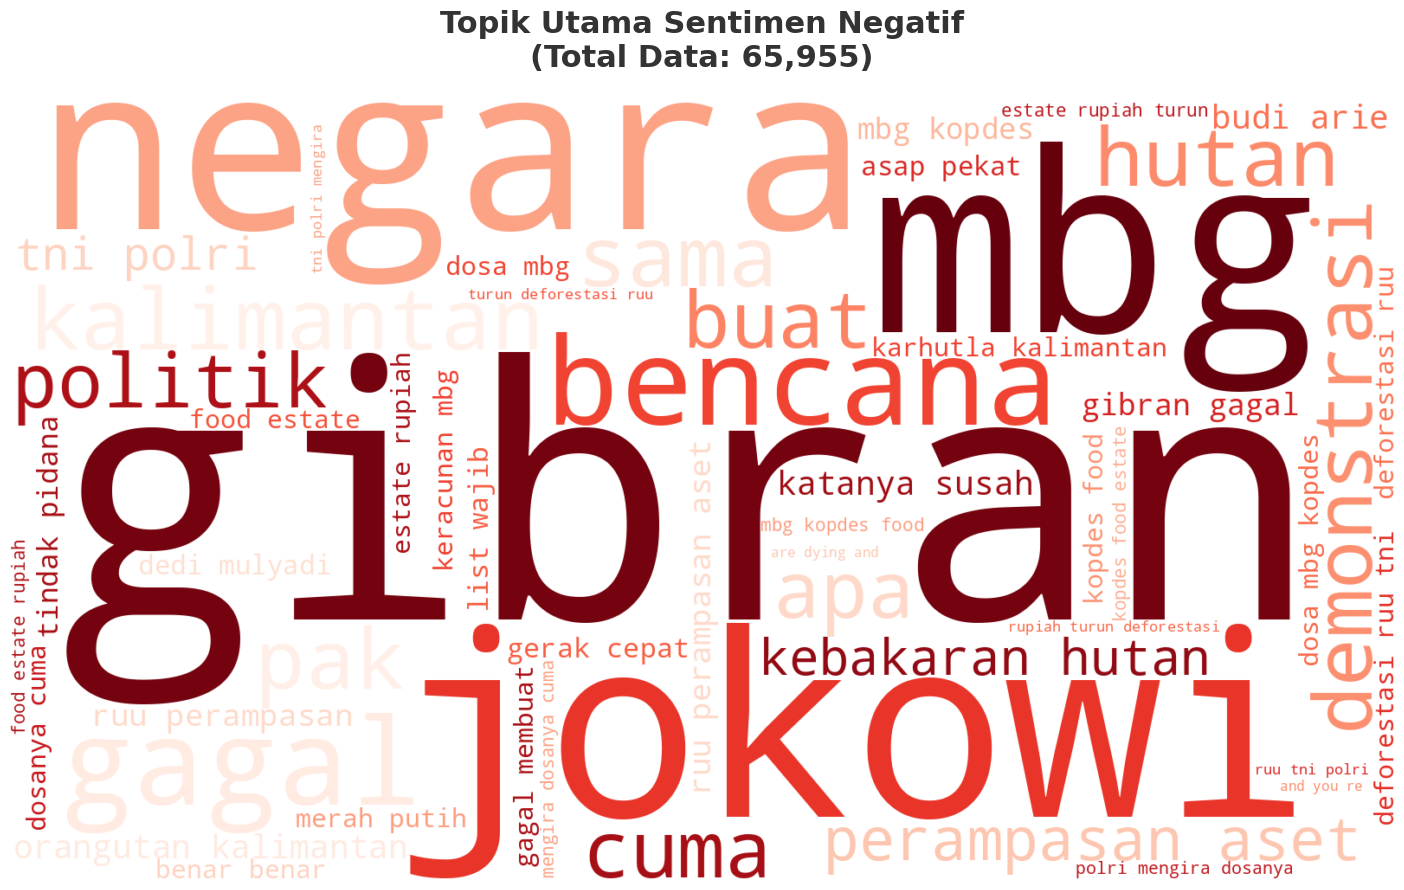

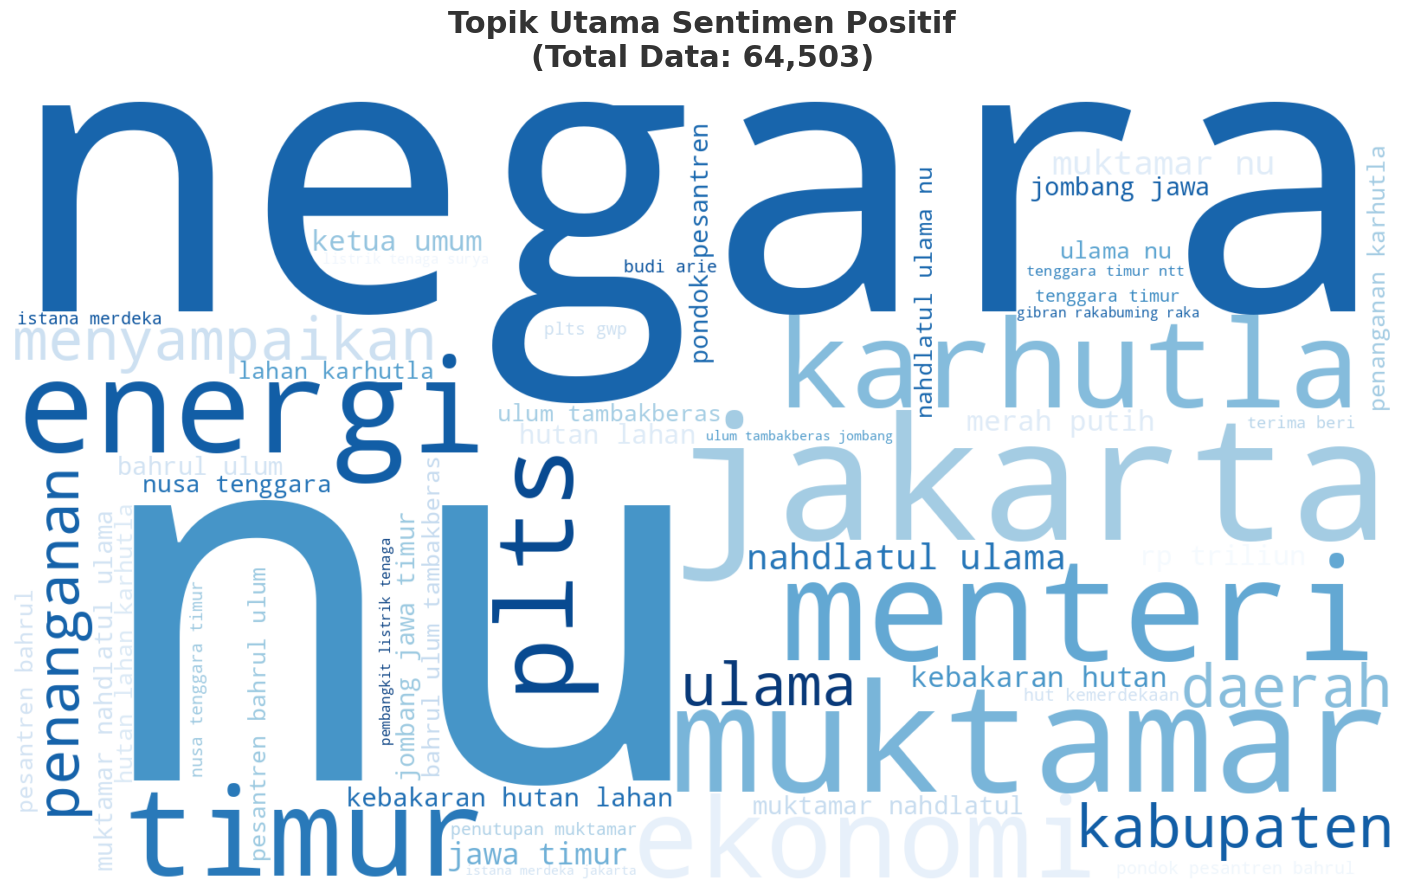

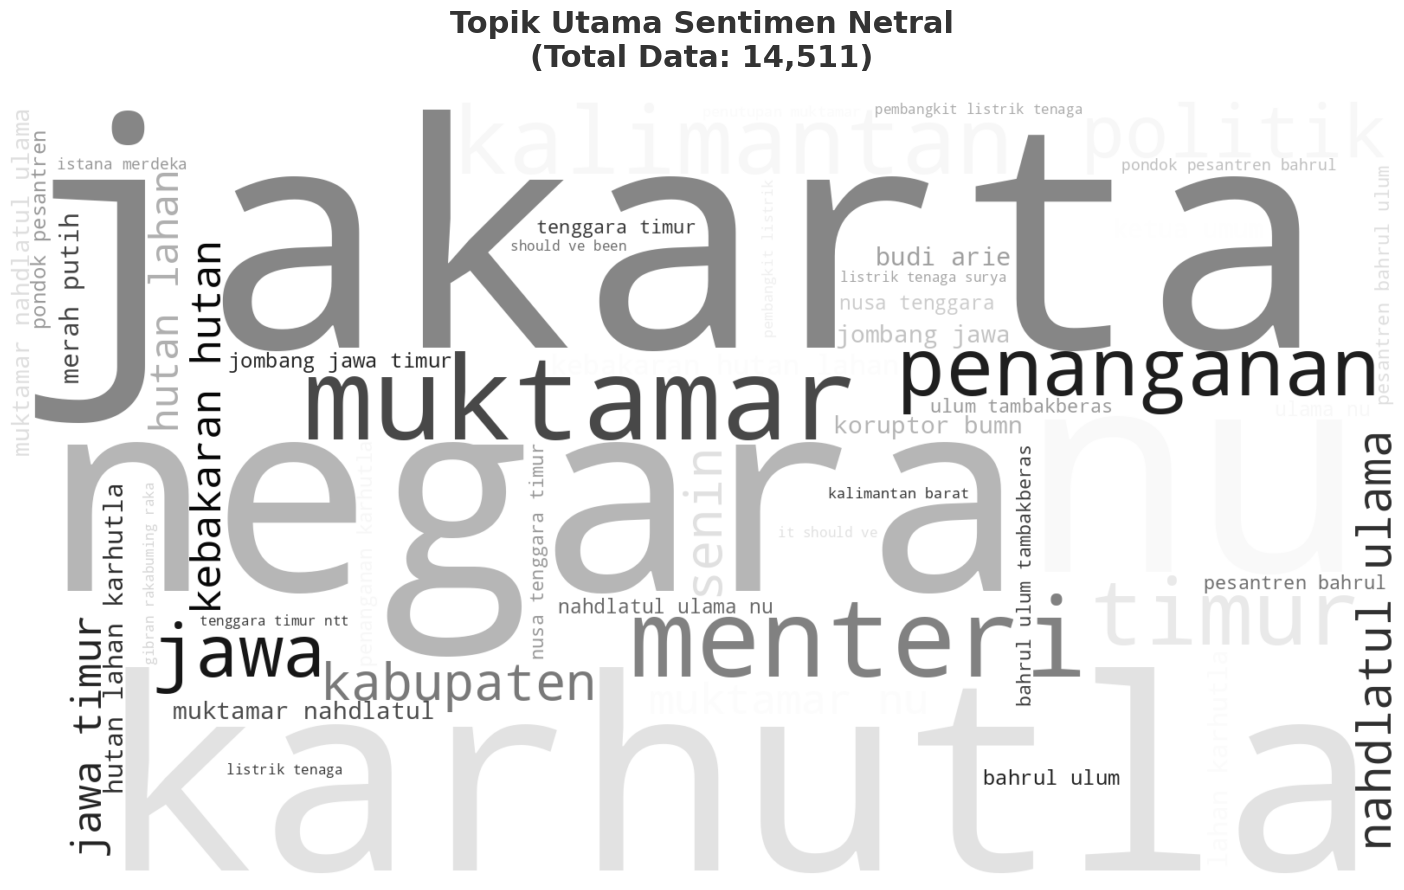

In [ ]:
# Konfigurasi Tampilan Profesional
TITLES = {
    'negative': "Topik Utama Sentimen Negatif",
    'positive': "Topik Utama Sentimen Positif",
    'neutral':  "Topik Utama Sentimen Netral"
}
FONT_SIZE = 22

# Loop untuk menghasilkan 3 gambar dengan tampilan bersih
for sentiment_label, data in sentiment_freqs.items():
    if data["count"] == 0: continue

    custom_title = TITLES.get(sentiment_label.lower(), f"Word Cloud {sentiment_label}")

    plt.figure(figsize=(16, 9))

    # Generate wordcloud ke dalam figure aktif
    generate_wordcloud_from_freqs(
        data["freqs"],
        sentiment_label,
        data["count"],
        max_words=100
    )

    # Kustomisasi Judul (Clean Look)
    plt.title(f"{custom_title}\n(Total Data: {data['count']:,})",
              fontsize=FONT_SIZE,
              pad=25,
              fontweight='bold',
              color='#333333')

    plt.tight_layout()
    plt.savefig(f"wordcloud_{sentiment_label.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()